In [1]:
import sherpa_utils
DATASET_DIR = "../../../../../datasets"

# ARIMA

In [2]:
%pip install sktime seaborn matplotlib pandas statsmodels pmdarima;

Note: you may need to restart the kernel to use updated packages.


In [3]:
import sktime
from matplotlib import pyplot
import matplotlib as plt
import seaborn
import datetime
import pandas as pd
import statsmodels

### All unique metricName values
- `compute.googleapis.com/instance/cpu/utilization`
- `compute.googleapis.com/instance/cpu/reserved_cores`
- `compute.googleapis.com/instance/cpu/usage_time`
- `compute.googleapis.com/instance/network/received_bytes_count`
- `compute.googleapis.com/instance/network/sent_bytes_count`
- `compute.googleapis.com/instance/network/received_packets_count`
- `compute.googleapis.com/instance/network/sent_packets_count`
- `compute.googleapis.com/instance/disk/read_bytes_count`
- `compute.googleapis.com/instance/disk/write_bytes_count`
- `compute.googleapis.com/instance/disk/read_ops_count`
- `compute.googleapis.com/instance/disk/write_ops_count`
### item_id = 806067928863076857

In [4]:
gcp_df = sherpa_utils.sherpa_preprocess(path=f"{DATASET_DIR}/gcpDataset.csv")
gcp_cpu_df = sherpa_utils.sherpa_get_feature(context_df=gcp_df, resource_id="806067928863076857", metricName="compute.googleapis.com/instance/cpu/utilization")
gcp_cpu_df = gcp_cpu_df.set_index("timestamp")
display(gcp_cpu_df.head())

,item_id,target,metricName
timestamp,,,
2026-05-30 02:45:00,806067928863076857,0.318452,compute.googleapis.com/instance/cpu/utilization
2026-05-30 02:50:00,806067928863076857,0.265010,compute.googleapis.com/instance/cpu/utilization
2026-05-30 02:55:00,806067928863076857,0.097326,compute.googleapis.com/instance/cpu/utilization
2026-05-30 03:00:00,806067928863076857,0.084856,compute.googleapis.com/instance/cpu/utilization
2026-05-30 03:05:00,806067928863076857,0.083133,compute.googleapis.com/instance/cpu/utilization


In [5]:
gcp_cpu_df.describe().T

,count,mean,std,min,25%,50%,75%,max
target,6592.0,0.087693,0.017559,0.077351,0.081218,0.084308,0.089051,0.751314


(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='target'>)

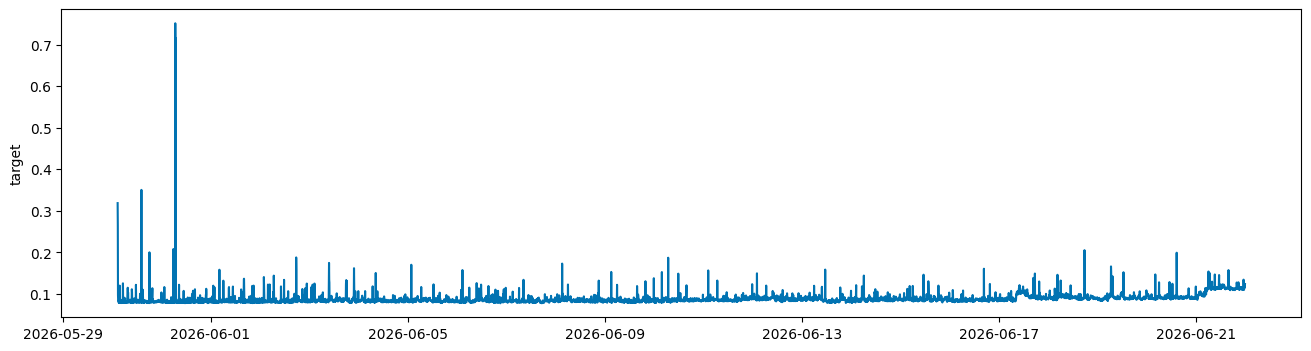

In [6]:
from sktime.utils.plotting import plot_series
plot_series(gcp_cpu_df["target"], markers=' ')

In [7]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(gcp_cpu_df["target"])
print(adf_result[1])

2.544863507332034e-18


In [8]:
from statsmodels.tsa.stattools import kpss

kpss_result = kpss(gcp_cpu_df["target"])
print(kpss_result[1])

0.01


/tmp/ipykernel_2928394/582151727.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(gcp_cpu_df["target"])


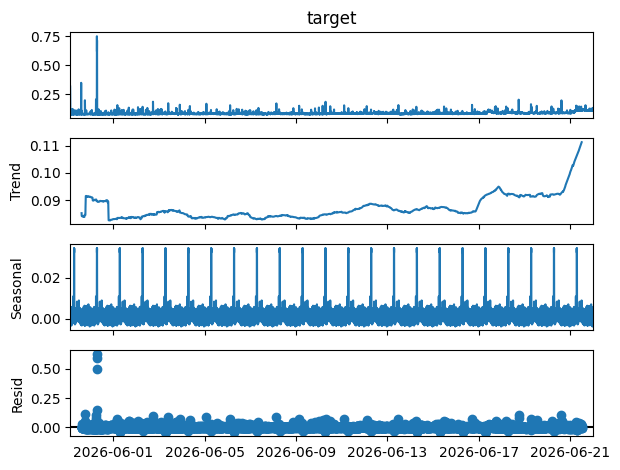

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(gcp_cpu_df["target"], model='additive', period=288)
result.plot()
pyplot.show()

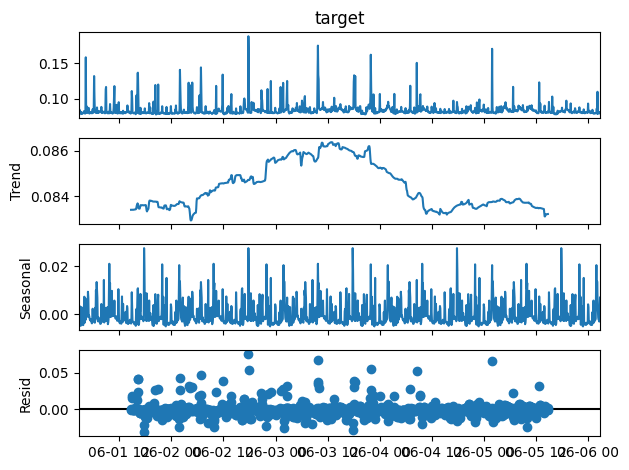

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(gcp_cpu_df["target"][576:2016], model='additive', period=288)
result.plot()
pyplot.show()

(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='target'>)

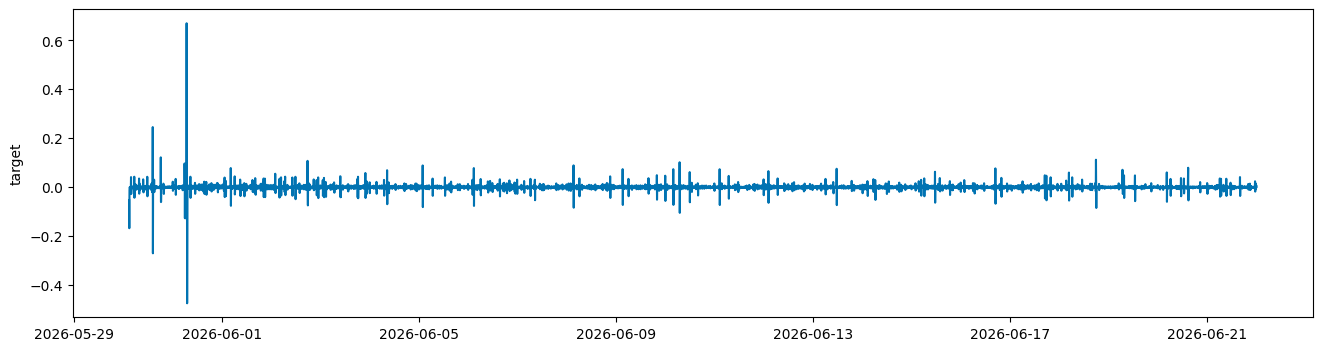

In [11]:
differenced = gcp_cpu_df["target"].diff().dropna()
plot_series(differenced, markers=' ')

In [12]:
from sktime.split import temporal_train_test_split
train, test = temporal_train_test_split(gcp_cpu_df["target"], test_size=36)

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

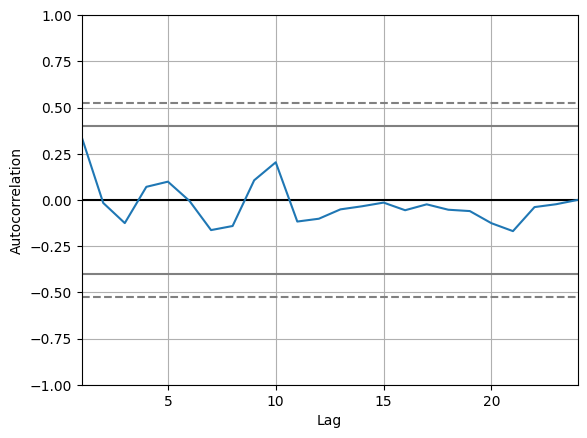

In [13]:
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(train[-24:])

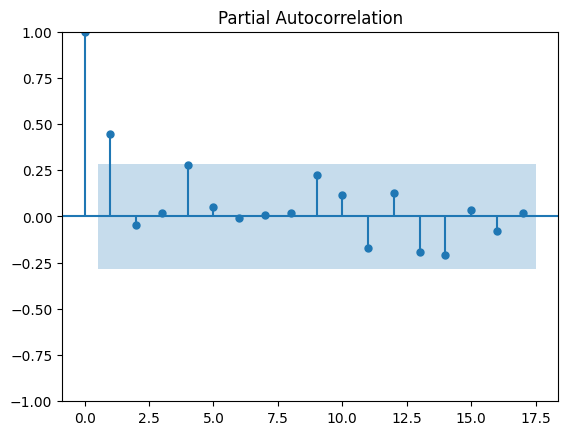

In [14]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(train[-48:])
pyplot.show()

In [16]:
import pmdarima as pm

auto_model = pm.auto_arima(
    train,
    start_p=1,
    start_q=1,
    test="adf",
    m=30,
    d=None,
    seasonal=False,
    information_criterion="aicc",
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True,
    trace=True
)

/home/cloudsherpa-collab/venvs/cloudsherpa/lib/python3.10/site-packages/pmdarima/arima/_validation.py:62: UserWarning: m (30) set for non-seasonal fit. Setting to 0
  warnings.warn("m (%i) set for non-seasonal fit. Setting to 0" % m)


Performing stepwise search to minimize aicc
 ARIMA(1,0,1)(0,0,0)[0]             : AICC=-36647.915, Time=0.32 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AICC=-13071.815, Time=0.06 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AICC=-36291.040, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AICC=-20286.822, Time=0.12 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AICC=-36613.164, Time=0.14 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AICC=-36957.274, Time=0.47 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AICC=-25119.287, Time=0.22 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AICC=-37228.000, Time=0.50 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AICC=inf, Time=0.91 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AICC=-36978.827, Time=0.82 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AICC=-37746.200, Time=0.60 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AICC=-28371.102, Time=0.39 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AICC=-37840.439, Time=0.85 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AICC=-30038.031, Time=0.42 s

In [17]:
print(auto_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 6556
Model:               SARIMAX(1, 0, 4)   Log Likelihood               18926.226
Date:                Tue, 07 Jul 2026   AIC                         -37840.452
Time:                        11:25:42   BIC                         -37799.723
Sample:                    05-30-2026   HQIC                        -37826.371
                         - 06-21-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9997   3.03e-05   3.29e+04      0.000       1.000       1.000
ma.L1         -0.3988      0.002   -221.694      0.000      -0.402      -0.395
ma.L2         -0.1170      0.002    -72.710      0.0

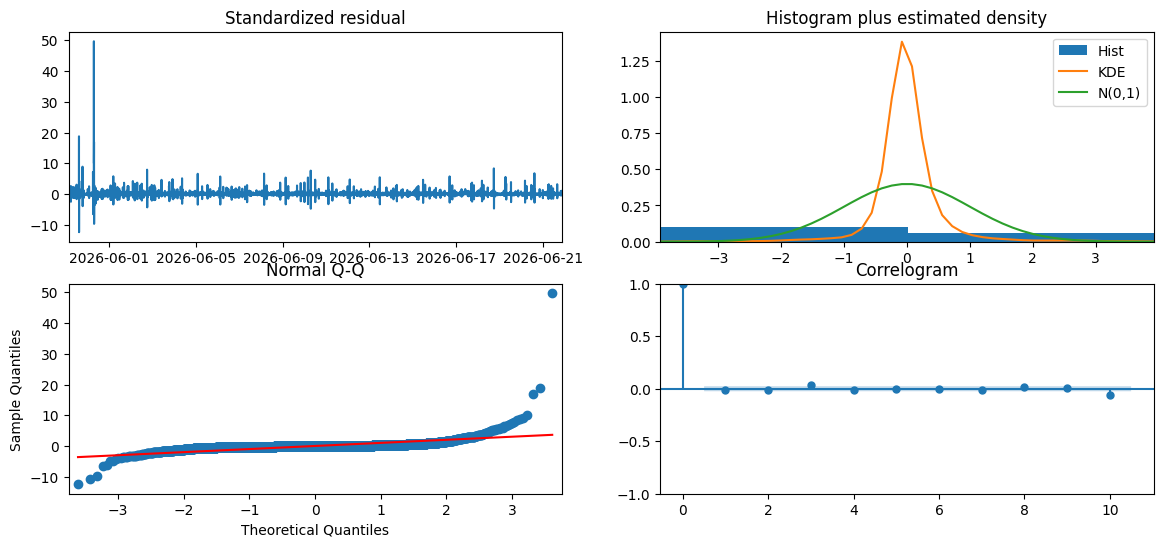

In [18]:
auto_model.plot_diagnostics(figsize=(14, 6))
pyplot.show()

In [19]:
history = train
auto_predictions = auto_model.predict(len(test))

In [22]:
display(auto_predictions.head())
test.loc[:, 'auto_predictions'] = auto_predictions.copy()

pyplot.plot(test['auto_predictions'], color='red', label='prediction')
pyplot.plot(test['production'], color='blue', label='actual')
pyplot.legend(loc="upper left")
pyplot.show()

2026-06-21 21:05:00    0.112253
2026-06-21 21:10:00    0.112838
2026-06-21 21:15:00    0.113039
2026-06-21 21:20:00    0.112977
2026-06-21 21:25:00    0.112946
Freq: 5min, dtype: float64

IndexingError: Too many indexers